<a href="https://colab.research.google.com/github/gowrignair21-ai/Clinical-Deterioration/blob/main/GOWRI_G_NAIR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv("/content/customer_churn.csv")

In [3]:
df1=df.copy()

In [4]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7036 non-null   float64
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7030 non-null   float64
 6   PhoneService      7030 non-null   object 
 7   MultipleLines     7030 non-null   object 
 8   InternetService   7006 non-null   object 
 9   OnlineSecurity    7028 non-null   object 
 10  OnlineBackup      7028 non-null   object 
 11  DeviceProtection  7028 non-null   object 
 12  TechSupport       7028 non-null   object 
 13  StreamingTV       7021 non-null   object 
 14  StreamingMovies   7029 non-null   object 
 15  Contract          7018 non-null   object 
 16  PaperlessBilling  7029 non-null   object 


In [5]:
df1.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0.0,Yes,No,1.0,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0.0,No,No,34.0,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0.0,No,No,2.0,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0.0,No,No,45.0,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0.0,No,No,2.0,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [7]:
df1.shape

(7043, 21)

In [9]:
df1.size

147903

In [10]:
df1.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7036.000000,7030.000000,7027.000000
mean,0.162024,32.367568,64.757855
std,0.368499,24.560644,30.091845
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [11]:
df1.dtypes

,0
customerID,object
gender,object
SeniorCitizen,float64
Partner,object
Dependents,object
tenure,float64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object


In [12]:
df1['Churn'].value_counts()

,count
Churn,
No,5174
Yes,1869


In [13]:
df1.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,7
Partner,0
Dependents,0
tenure,13
PhoneService,13
MultipleLines,13
InternetService,37
OnlineSecurity,15


In [15]:
df1[df1.isnull().any(axis=1)]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
14,5129-JLPIS,Male,0.0,No,No,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,Electronic check,105.50,2686.05,No
15,3655-SNQYZ,Female,0.0,Yes,Yes,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,Credit card (automatic),113.25,7895.15,No
16,8191-XWSZG,Female,0.0,No,No,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,Mailed check,20.65,1022.95,No
17,9959-WOFKT,Male,0.0,No,Yes,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,Bank transfer (automatic),106.70,7382.25,No
18,4190-MFLUW,Female,0.0,Yes,Yes,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,Credit card (automatic),55.20,528.35,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
448,5168-MSWXT,Male,0.0,Yes,Yes,8.0,Yes,No,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,94.75,NaN,No
449,1090-ESELR,Male,0.0,Yes,Yes,72.0,Yes,No,Fiber optic,Yes,...,No,Yes,Yes,Yes,Two year,No,Bank transfer (automatic),105.50,NaN,No
450,8592-PLTMQ,Female,0.0,No,No,64.0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,No,Mailed check,24.70,NaN,No
451,5760-WRAHC,Female,1.0,No,No,22.0,Yes,No,DSL,Yes,...,Yes,Yes,No,Yes,Month-to-month,Yes,Mailed check,69.75,NaN,No


In [21]:
df1['TotalCharges']=pd.to_numeric(df1['TotalCharges'],errors='coerce')

In [22]:
numerical_cols_with_nan=df1.select_dtypes(include=np.number)
categorical_cols_with_nan=df1.select_dtypes(include='object')

print(f"Numerical columns with missing values: {numerical_cols_with_nan}")
print(f"Categorical columns with missing values: {categorical_cols_with_nan}")

for col in numerical_cols_with_nan:
  median_value=df1[col].median()
  df1[col].fillna(median_value,inplace=True)
  print(f"Filled missing values in '{col}' with median: {median_value}")

for col in categorical_cols_with_nan:
  mode_value=df1[col].mode()[0]
  df1[col].fillna(mode_value,inplace=True)
  print(f"Filled missing values in '{col}' with mode: {mode_value}")


Numerical columns with missing values:       SeniorCitizen  tenure  MonthlyCharges  TotalCharges
0               0.0     1.0           29.85         29.85
1               0.0    34.0           56.95       1889.50
2               0.0     2.0           53.85        108.15
3               0.0    45.0           42.30       1840.75
4               0.0     2.0           70.70        151.65
...             ...     ...             ...           ...
7038            0.0    24.0           84.80       1990.50
7039            0.0    72.0          103.20       7362.90
7040            0.0    11.0           29.60        346.45
7041            1.0     4.0           74.40        306.60
7042            0.0    66.0          105.65       6844.50

[7043 rows x 4 columns]
Categorical columns with missing values:       customerID  gender Partner Dependents PhoneService     MultipleLines  \
0     7590-VHVEG  Female     Yes         No           No  No phone service   
1     5575-GNVDE    Male      No         No

/tmp/ipykernel_4686/3816846195.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df1[col].fillna(median_value,inplace=True)
/tmp/ipykernel_4686/3816846195.py:14: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using

In [35]:
df1.isnull().sum()

,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0
OnlineBackup,0


In [28]:
#dropping customer id
df1.drop('customerID',axis=1,inplace=True)

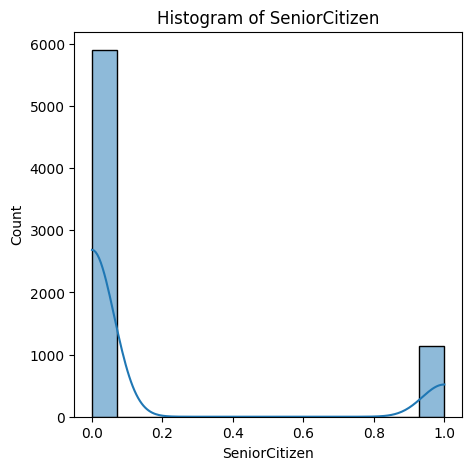

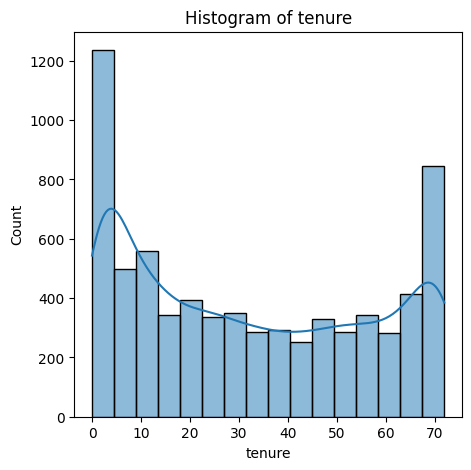

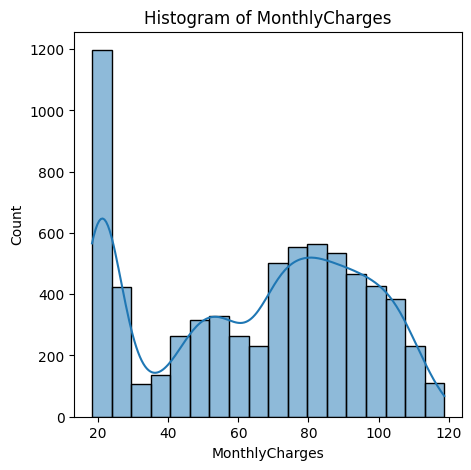

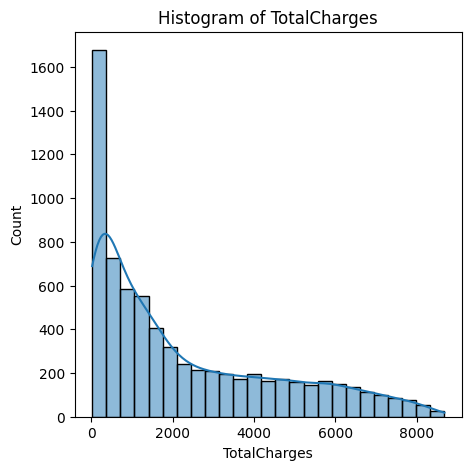

In [30]:
#Histogram
num_cols=df1.select_dtypes(include=np.number).columns
for col in num_cols:
  plt.figure(figsize=(5,5))
  sns.histplot(df1[col],kde=True)
  plt.title(f"Histogram of {col}")
  plt.show()


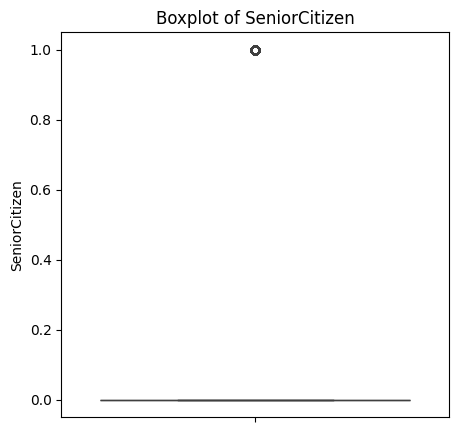

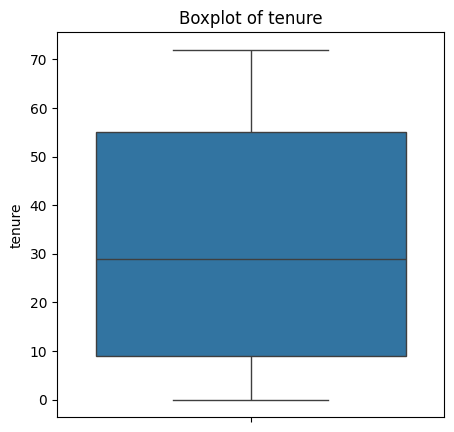

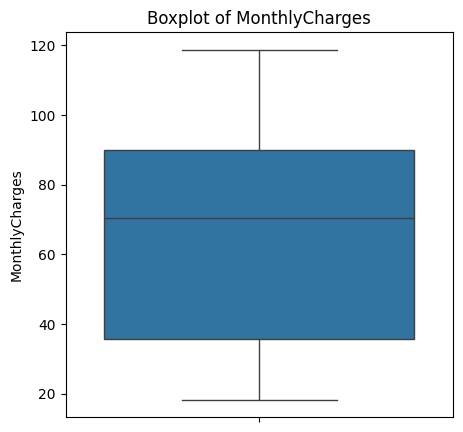

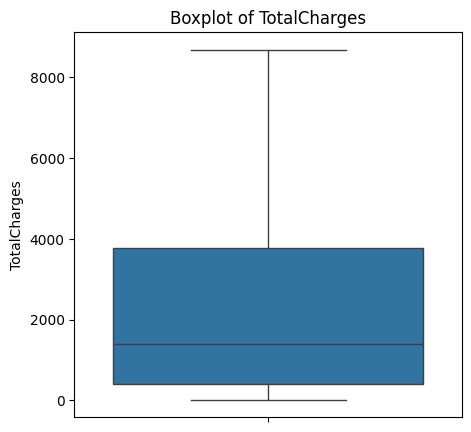

In [31]:
#Boxplot
num_cols=df1.select_dtypes(include=np.number).columns
for col in num_cols:
  plt.figure(figsize=(5,5))
  sns.boxplot(df1[col])
  plt.title(f"Boxplot of {col}")
  plt.show()

<Axes: >

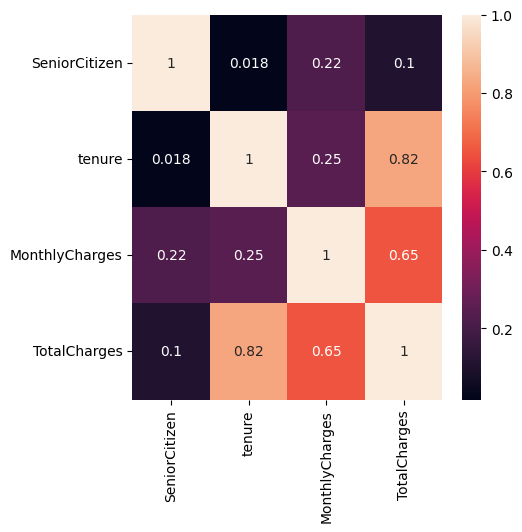

In [32]:
#Heat map
plt.figure(figsize=(5,5))
sns.heatmap(df1.corr(numeric_only=True),annot=True)

/tmp/ipykernel_4686/1196523981.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col,data=df1,palette="Set3")


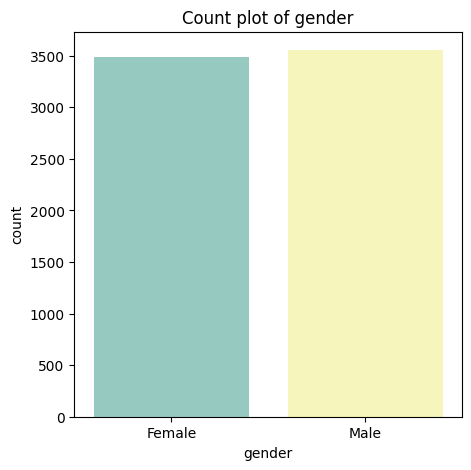

/tmp/ipykernel_4686/1196523981.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col,data=df1,palette="Set3")


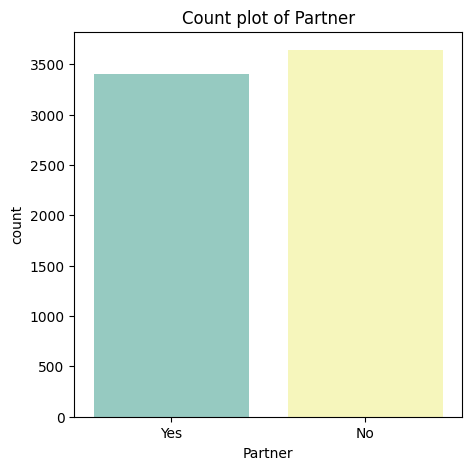

/tmp/ipykernel_4686/1196523981.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col,data=df1,palette="Set3")


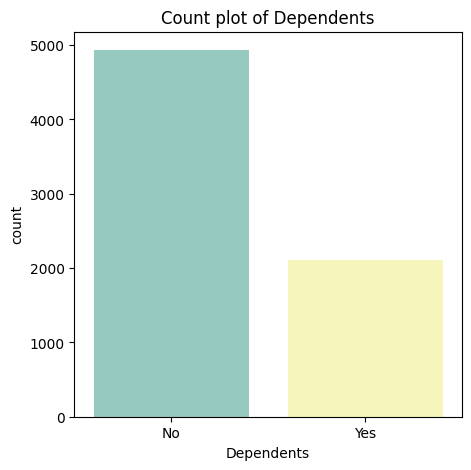

/tmp/ipykernel_4686/1196523981.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col,data=df1,palette="Set3")


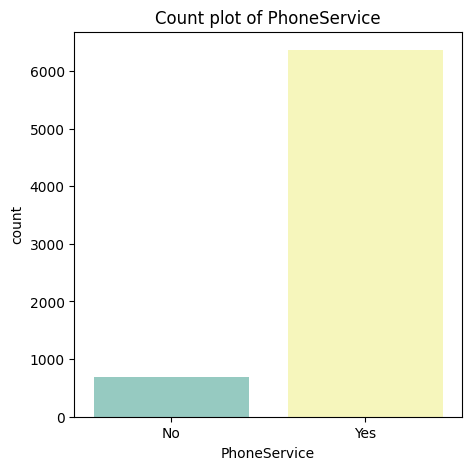

/tmp/ipykernel_4686/1196523981.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col,data=df1,palette="Set3")


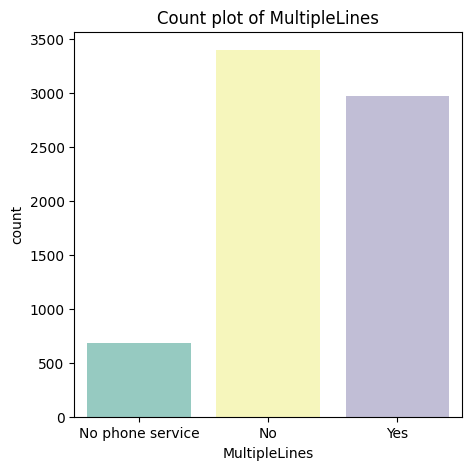

/tmp/ipykernel_4686/1196523981.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col,data=df1,palette="Set3")


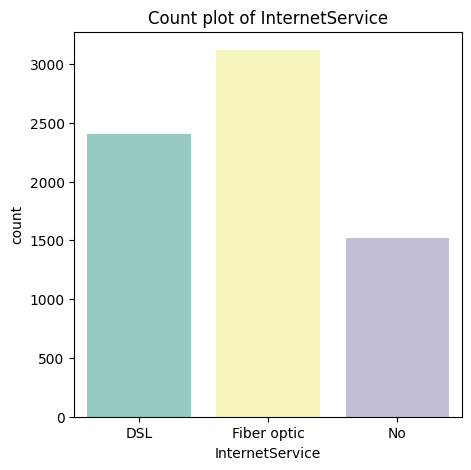

/tmp/ipykernel_4686/1196523981.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col,data=df1,palette="Set3")


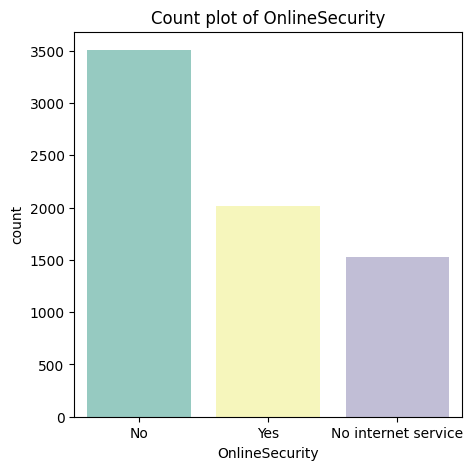

/tmp/ipykernel_4686/1196523981.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col,data=df1,palette="Set3")


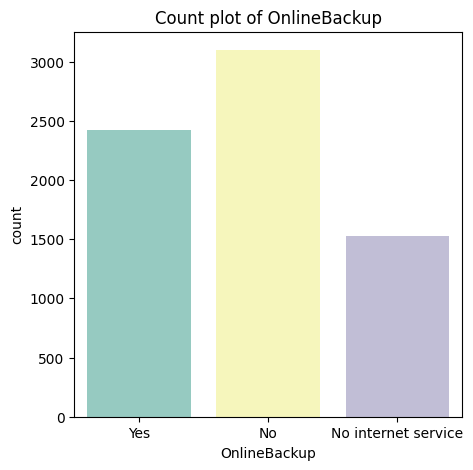

/tmp/ipykernel_4686/1196523981.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col,data=df1,palette="Set3")


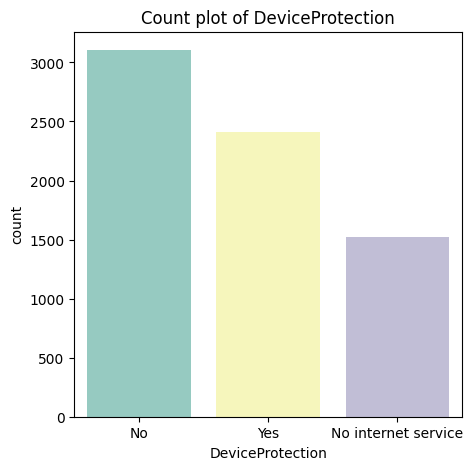

/tmp/ipykernel_4686/1196523981.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col,data=df1,palette="Set3")


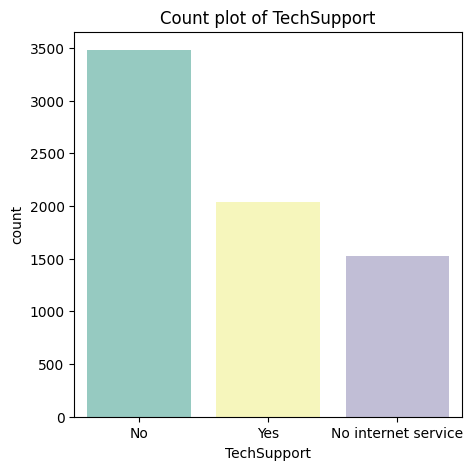

/tmp/ipykernel_4686/1196523981.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col,data=df1,palette="Set3")


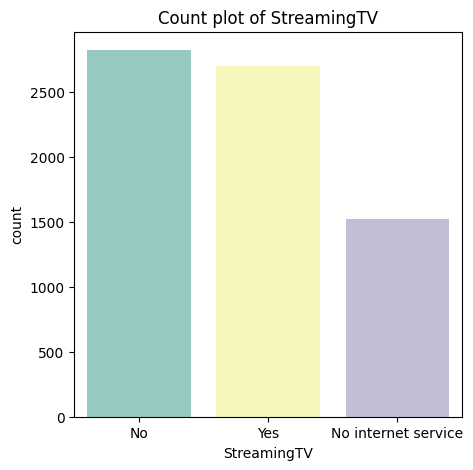

/tmp/ipykernel_4686/1196523981.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col,data=df1,palette="Set3")


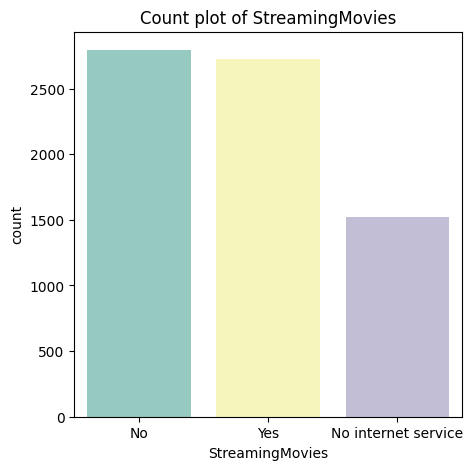

/tmp/ipykernel_4686/1196523981.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col,data=df1,palette="Set3")


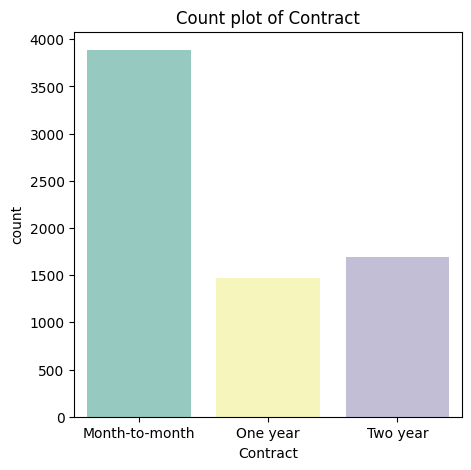

/tmp/ipykernel_4686/1196523981.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col,data=df1,palette="Set3")


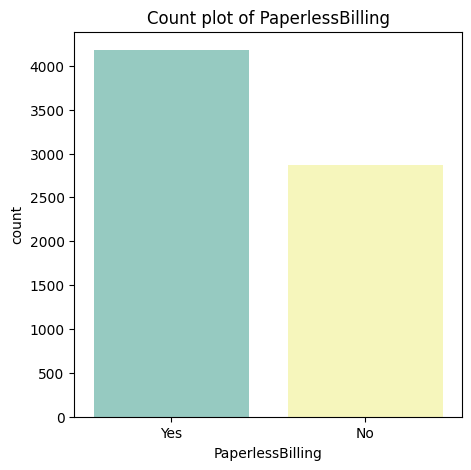

/tmp/ipykernel_4686/1196523981.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col,data=df1,palette="Set3")


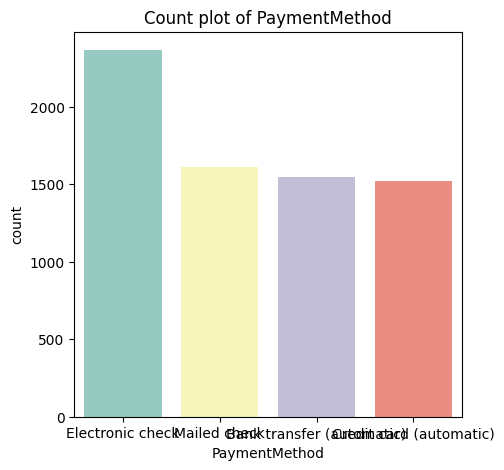

/tmp/ipykernel_4686/1196523981.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col,data=df1,palette="Set3")


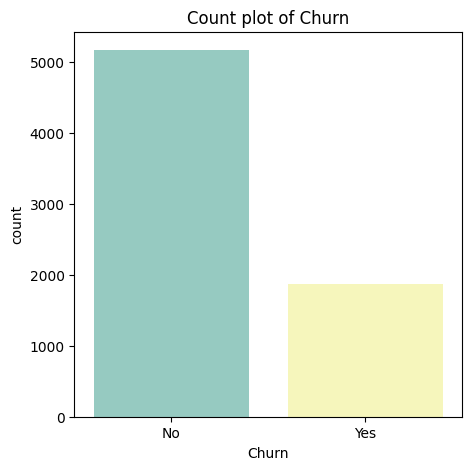

In [34]:
#Count plots for categorical features
cat_cols=df1.select_dtypes(include='object').columns
for col in cat_cols:
  plt.figure(figsize=(5,5))
  sns.countplot(x=col,data=df1,palette="Set3")
  plt.title(f"Count plot of {col}")
  plt.show()

In [36]:
df1.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0.0,Yes,No,1.0,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0.0,No,No,34.0,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0.0,No,No,2.0,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0.0,No,No,45.0,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0.0,No,No,2.0,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [37]:
#One-Hot encoding
df1=pd.get_dummies(df1,columns=['gender','Partner','Dependents','PhoneService','MultipleLines','InternetService','OnlineSecurity','OnlineBackup','DeviceProtection','TechSupport','StreamingTV','StreamingMovies','PaperlessBilling','PaymentMethod'])
bool_cols=df1.select_dtypes(include='bool').columns
df1[bool_cols]=df1[bool_cols].astype(int)
df1.head()

,SeniorCitizen,tenure,Contract,MonthlyCharges,TotalCharges,Churn,gender_Female,gender_Male,Partner_No,Partner_Yes,...,StreamingTV_Yes,StreamingMovies_No,StreamingMovies_No internet service,StreamingMovies_Yes,PaperlessBilling_No,PaperlessBilling_Yes,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0.0,1.0,Month-to-month,29.85,29.85,No,1,0,0,1,...,0,1,0,0,0,1,0,0,1,0
1,0.0,34.0,One year,56.95,1889.50,No,0,1,1,0,...,0,1,0,0,1,0,0,0,0,1
2,0.0,2.0,Month-to-month,53.85,108.15,Yes,0,1,1,0,...,0,1,0,0,0,1,0,0,0,1
3,0.0,45.0,One year,42.30,1840.75,No,0,1,1,0,...,0,1,0,0,1,0,1,0,0,0
4,0.0,2.0,Month-to-month,70.70,151.65,Yes,1,0,1,0,...,0,1,0,0,0,1,0,0,1,0


In [38]:
#Label encoding
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df1['Churn']=le.fit_transform(df1['Churn'])

In [40]:
#Ordinal encoding
from sklearn.preprocessing import OrdinalEncoder
oe=OrdinalEncoder()
df1['Contract']=oe.fit_transform(df1[['Contract']])

In [44]:
#Train-test split
X=df1.drop('Churn',axis=1)
y=df1['Churn']
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,stratify=y,random_state=42)

In [46]:
df1['Churn'].value_counts()

,count
Churn,
0,5174
1,1869


In [49]:
#Hybrid sampling method
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline

smote=SMOTE(sampling_strategy='minority',random_state=42)
undersampler= RandomUnderSampler(sampling_strategy='majority',random_state=42)
hybrid_sampler=Pipeline([('smote',smote),('undersampler',undersampler)])
X_train_hybrid,y_train_hybrid=hybrid_sampler.fit_resample(X_train,y_train)

print("Shape of original X_train:", X_train.shape)
print("Shape of hybrid-sampled X_train:", X_train_hybrid.shape)
print("Value counts of original y_train:\n", y_train.value_counts())
print("Value counts of hybrid-sampled y_train:\n", y_train_hybrid.value_counts())

Shape of original X_train: (5634, 43)
Shape of hybrid-sampled X_train: (8278, 43)
Value counts of original y_train:
 Churn
0    4139
1    1495
Name: count, dtype: int64
Value counts of hybrid-sampled y_train:
 Churn
0    4139
1    4139
Name: count, dtype: int64


In [50]:
from sklearn.preprocessing import StandardScaler

numerical_cols_to_scale = ['tenure', 'MonthlyCharges', 'TotalCharges', 'Contract']

scaler= StandardScaler()

X_train_hybrid[numerical_cols_to_scale] = scaler.fit_transform(X_train_hybrid[numerical_cols_to_scale])
X_test[numerical_cols_to_scale] = scaler.transform(X_test[numerical_cols_to_scale])


In [53]:
 # LogisticRegression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

lr=LogisticRegression(random_state=42,max_iter=1000,solver='saga',class_weight='balanced')
lr.fit(X_train_hybrid,y_train_hybrid)
y_pred1=lr.predict(X_test)

print("acc1=",accuracy_score(y_test,y_pred1))
print("cm1=",confusion_matrix(y_test,y_pred1))
print(classification_report(y_test,y_pred1))

acc1= 0.7998580553584103
cm1= [[904 131]
 [151 223]]
              precision    recall  f1-score   support

           0       0.86      0.87      0.87      1035
           1       0.63      0.60      0.61       374

    accuracy                           0.80      1409
   macro avg       0.74      0.73      0.74      1409
weighted avg       0.80      0.80      0.80      1409



In [54]:
# DecisionTreeClassifier
dt_model=DecisionTreeClassifier(criterion='gini',max_depth=7,min_samples_split=20,random_state=42,min_samples_leaf=20,class_weight='balanced')
dt_model.fit(X_train_hybrid,y_train_hybrid)
y_pred2=dt_model.predict(X_test)

print("acc2=",accuracy_score(y_test,y_pred2))
print("cm2=",confusion_matrix(y_test,y_pred2))
print(classification_report(y_test,y_pred2))

acc2= 0.7579843860894251
cm2= [[818 217]
 [124 250]]
              precision    recall  f1-score   support

           0       0.87      0.79      0.83      1035
           1       0.54      0.67      0.59       374

    accuracy                           0.76      1409
   macro avg       0.70      0.73      0.71      1409
weighted avg       0.78      0.76      0.77      1409



In [55]:
# RandomForestClassifier
rf_model=RandomForestClassifier(n_estimators=200,max_depth=25,min_samples_split=5,min_samples_leaf=2,class_weight='balanced',random_state=42)
rf_model.fit(X_train_hybrid,y_train_hybrid)
y_pred3=rf_model.predict(X_test)

from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
print("acc3=",accuracy_score(y_test,y_pred3))
print("cm3=",confusion_matrix(y_test,y_pred3))
print(classification_report(y_test,y_pred3))

acc3= 0.7757274662881476
cm3= [[886 149]
 [167 207]]
              precision    recall  f1-score   support

           0       0.84      0.86      0.85      1035
           1       0.58      0.55      0.57       374

    accuracy                           0.78      1409
   macro avg       0.71      0.70      0.71      1409
weighted avg       0.77      0.78      0.77      1409



In [58]:
# KNeighborsClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier

knn_model=KNeighborsClassifier(n_neighbors=10)
knn_model.fit(X_train_hybrid,y_train_hybrid)
y_pred4=knn_model.predict(X_test)

print("acc4=",accuracy_score(y_test,y_pred4))
print("cm4=",confusion_matrix(y_test,y_pred4))
print(classification_report(y_test,y_pred4))

acc4= 0.7707594038325053
cm4= [[861 174]
 [149 225]]
              precision    recall  f1-score   support

           0       0.85      0.83      0.84      1035
           1       0.56      0.60      0.58       374

    accuracy                           0.77      1409
   macro avg       0.71      0.72      0.71      1409
weighted avg       0.78      0.77      0.77      1409



In [59]:
# XGBoost Classifier
neg_count_hybrid = y_train_hybrid.value_counts()[0]
pos_count_hybrid = y_train_hybrid.value_counts()[1]
scale_pos_weight_value = neg_count_hybrid / pos_count_hybrid

xgb_model = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    use_label_encoder=False,
    random_state=42,
    n_estimators=500,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    gamma=0.1,
    min_child_weight=5,
    reg_alpha=0.1,
    reg_lambda=1.5,
    scale_pos_weight=scale_pos_weight_value
)

xgb_model.fit(X_train_hybrid, y_train_hybrid)
y_pred_xgb = xgb_model.predict(X_test)

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Accuracy of XGBoost model:", accuracy_score(y_test, y_pred_xgb))
print("\nConfusion Matrix for XGBoost model:\n", confusion_matrix(y_test, y_pred_xgb))
print("\nClassification Report for XGBoost model:\n", classification_report(y_test, y_pred_xgb))

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [07:27:44] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Accuracy of XGBoost model: 0.7920511000709723

Confusion Matrix for XGBoost model:
 [[903 132]
 [161 213]]

Classification Report for XGBoost model:
               precision    recall  f1-score   support

           0       0.85      0.87      0.86      1035
           1       0.62      0.57      0.59       374

    accuracy                           0.79      1409
   macro avg       0.73      0.72      0.73      1409
weighted avg       0.79      0.79      0.79      1409



In [60]:
from sklearn.model_selection import RandomizedSearchCV

# Define the parameter grid for XGBoost
param_dist = {
    'n_estimators': [100, 200, 300, 400, 500],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [3, 5, 7, 9],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'gamma': [0, 0.1, 0.2, 0.3],
    'min_child_weight': [1, 3, 5, 7],
    'reg_alpha': [0, 0.005, 0.01, 0.05, 0.1],
    'reg_lambda': [0.5, 1, 1.5, 2]
}

# Initialize XGBoost Classifier with the previously calculated scale_pos_weight
xgb_base_model = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    use_label_encoder=False,
    random_state=42,
    scale_pos_weight=scale_pos_weight_value # Use the scale_pos_weight calculated earlier
)

# Set up RandomizedSearchCV
# n_iter determines how many parameter settings are sampled. Lower for faster results.
# scoring='f1' optimizes for the F1-score of the positive class (churn).
random_search = RandomizedSearchCV(
    estimator=xgb_base_model,
    param_distributions=param_dist,
    n_iter=50, # Number of parameter settings that are sampled. Reduce for quicker run.
    scoring='f1',
    cv=5,
    verbose=1,
    n_jobs=-1, # Use all available cores
    random_state=42
)

# Fit the random search to the data
random_search.fit(X_train_hybrid, y_train_hybrid)

# Print the best parameters and the best score
print("Best parameters found: ", random_search.best_params_)
print("Best F1-score found: ", random_search.best_score_)

# Get the best model
best_xgb_model = random_search.best_estimator_

# Make predictions with the best model
y_pred_xgb_tuned = best_xgb_model.predict(X_test)

# Evaluate the tuned model
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("\nAccuracy of Tuned XGBoost model:", accuracy_score(y_test, y_pred_xgb_tuned))
print("\nConfusion Matrix for Tuned XGBoost model:\n", confusion_matrix(y_test, y_pred_xgb_tuned))
print("\nClassification Report for Tuned XGBoost model:\n", classification_report(y_test, y_pred_xgb_tuned))

Fitting 5 folds for each of 50 candidates, totalling 250 fits


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [07:34:37] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best parameters found:  {'subsample': 1.0, 'reg_lambda': 0.5, 'reg_alpha': 0.05, 'n_estimators': 300, 'min_child_weight': 7, 'max_depth': 5, 'learning_rate': 0.01, 'gamma': 0.3, 'colsample_bytree': 1.0}
Best F1-score found:  0.833033107926445

Accuracy of Tuned XGBoost model: 0.7806955287437899

Confusion Matrix for Tuned XGBoost model:
 [[852 183]
 [126 248]]

Classification Report for Tuned XGBoost model:
               precision    recall  f1-score   support

           0       0.87      0.82      0.85      1035
           1       0.58      0.66      0.62       374

    accuracy                           0.78      1409
   macro avg       0.72      0.74      0.73      1409
weighted avg       0.79      0.78      0.79      1409

